In [1]:
# Cell 1 — Imports and environment setup

import os
import re
import gc
import json
import time
import math
import pickle
import random
import hashlib
import platform
import datetime as dt
from pathlib import Path
from typing import Dict, Any, Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse import csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [2]:

# Cell 2 — Central configuration

CONFIG: Dict[str, Any] = {
    "experiment_name": "SLP_TF-IDF_research_ready_v1",
    "run_group": "main_comparison_v1",
    "random_seed": 30,

    # Original Kaggle path from the prototype notebook. Change only if your dataset location changes.
    "data_path": "/kaggle/input/datasets/anthony73/kaggle-environment-extremism-detection/extremism_dataset_final.csv",
    "text_col": "Original_Message",
    "label_col": "Extremism_Label",
    "id_col": "row_id",

    # Label convention: positive class = extremist.
    "label_map": {
        "NON_EXTREMIST": 0,
        "EXTREMIST": 1,
    },

    # Research-valid split protocol. Test is not touched until final evaluation.
    "splits": {
        "train_size": 0.70,
        "val_size": 0.15,
        "test_size": 0.15,
        "stratify": True,
        "split_version": "split_v1_seed30_70_15_15",
    },

    # Minimal text cleanup only. Avoid aggressive cleaning unless justified and applied consistently.
    "preprocessing": {
        "collapse_whitespace": True,
        "strip_text": True,
        "drop_empty_text": True,
        "lowercase_in_vectorizer": True,
        "stop_words": "english",
    },

    "features": {
        "type": "tfidf",
        "max_features": 20000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
        "dtype": "float32",
    },

    # This SLP is intentionally a linear binary classifier over TF-IDF features.
    "model": {
        "family": "single_layer_perceptron",
        "lr": 0.001,
        "weight_decay": 1e-4,
        "batch_size": 32,
        "epochs": 30,
        "early_stopping_patience": 5,
        "use_pos_weight": True,
        "max_dense_elements": 200_000_000,  # guardrail for dense TF-IDF -> PyTorch conversion
    },

    "evaluation": {
        "primary_metric": "positive_f1",
        "threshold_strategy": "maximize_val_f1",  # options: fixed_0.5, maximize_val_f1, recall_at_min_precision, precision_at_min_recall
        "fixed_threshold": 0.5,
        "min_precision": 0.80,
        "min_recall": 0.80,
        "threshold_grid_size": 199,
    },

    "artifacts": {
        "save_text_in_error_files": False,  # safer default for sensitive/extremism text
        "top_k_error_examples": 25,
        "top_k_local_explanations": 15,
        "top_k_global_features": 50,
    },
}

# Portable output root: Kaggle if available, otherwise local outputs/.
if Path("/kaggle/working").exists():
    WORKING_ROOT = Path("/kaggle/working")
else:
    WORKING_ROOT = Path("./outputs")

RUN_TIMESTAMP = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ID = f"{CONFIG['experiment_name']}_{RUN_TIMESTAMP}_seed{CONFIG['random_seed']}"
OUTPUT_DIR = WORKING_ROOT / RUN_ID
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
PLOT_DIR = OUTPUT_DIR / "plots"
EXPLAIN_DIR = OUTPUT_DIR / "explanations"
ERROR_DIR = OUTPUT_DIR / "error_analysis"

for path in [OUTPUT_DIR, ARTIFACT_DIR, PLOT_DIR, EXPLAIN_DIR, ERROR_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Run ID: {RUN_ID}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Run ID: SLP_TF-IDF_research_ready_v1_20260620_203014_seed30
Output directory: /kaggle/working/SLP_TF-IDF_research_ready_v1_20260620_203014_seed30


In [3]:

# Cell 3 — Reproducibility and utility functions

def set_global_seed(seed: int) -> None:
    """Set seeds for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def json_safe(obj):
    """Convert common NumPy/PyTorch objects to JSON-safe Python objects."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, tuple):
        return list(obj)
    return str(obj)


def sha256_file(path: Path, chunk_size: int = 1_048_576) -> str:
    """Return SHA256 hash for a file."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def stable_text_hash(text: str) -> str:
    return hashlib.sha256(str(text).encode("utf-8", errors="ignore")).hexdigest()[:16]


def config_hash(config: Dict[str, Any]) -> str:
    payload = json.dumps(config, sort_keys=True, default=json_safe)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:16]


def save_json(obj: Dict[str, Any], path: Path) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=json_safe)


def clean_text(text: Any, cfg: Dict[str, Any]) -> str:
    """Minimal, auditable text cleanup."""
    text = str(text)
    if cfg["collapse_whitespace"]:
        text = re.sub(r"\s+", " ", text)
    if cfg["strip_text"]:
        text = text.strip()
    return text


set_global_seed(CONFIG["random_seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Config hash: {config_hash(CONFIG)}")


Device: cuda
Config hash: 26e6b2e5be9dc1dd


In [4]:

# Cell 4 — Save config and environment metadata before training

metadata = {
    "run_id": RUN_ID,
    "created_at": dt.datetime.now().isoformat(),
    "experiment_name": CONFIG["experiment_name"],
    "run_group": CONFIG["run_group"],
    "config_hash": config_hash(CONFIG),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device": str(DEVICE),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
}

save_json(CONFIG, OUTPUT_DIR / "config.json")
save_json(metadata, OUTPUT_DIR / "metadata.json")

print("Saved config and metadata.")


Saved config and metadata.


In [5]:

# Cell 5 — Load and validate dataset

data_path = Path(CONFIG["data_path"])
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. Update CONFIG['data_path'] to the correct CSV path."
    )

df_raw = pd.read_csv(data_path)

required_cols = [CONFIG["text_col"], CONFIG["label_col"]]
missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df_raw.columns)}")

print(f"Raw shape: {df_raw.shape}")
print("Columns:", list(df_raw.columns))
display(df_raw.head())
print("Raw label distribution:")
print(df_raw[CONFIG["label_col"]].value_counts(dropna=False))


Raw shape: (3000, 2)
Columns: ['Original_Message', 'Extremism_Label']


,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST
3,halal factories should burn to the ground,EXTREMIST
4,nhs should burn to the ground,EXTREMIST


Raw label distribution:
Extremism_Label
NON_EXTREMIST    1603
EXTREMIST        1397
Name: count, dtype: int64


In [6]:

# Cell 6 — Clean data, map labels, create stable row IDs, and audit class balance

df = df_raw[[CONFIG["text_col"], CONFIG["label_col"]]].copy()

# Drop missing required values.
df = df.dropna(subset=[CONFIG["text_col"], CONFIG["label_col"]]).copy()

# Clean text.
df[CONFIG["text_col"]] = df[CONFIG["text_col"]].apply(
    lambda x: clean_text(x, CONFIG["preprocessing"])
)

if CONFIG["preprocessing"]["drop_empty_text"]:
    df = df[df[CONFIG["text_col"]].str.len() > 0].copy()

# Map labels if they are strings. If already numeric, validate binary values.
label_col = CONFIG["label_col"]
if df[label_col].dtype == object:
    df[label_col] = df[label_col].map(CONFIG["label_map"])

if df[label_col].isna().any():
    bad_values = df_raw.loc[df[label_col].isna(), label_col].value_counts(dropna=False)
    raise ValueError(f"Unexpected or unmapped label values found:\n{bad_values}")

df[label_col] = df[label_col].astype(int)
unique_labels = sorted(df[label_col].unique().tolist())
if unique_labels != [0, 1]:
    raise ValueError(f"Expected binary labels [0, 1], found: {unique_labels}")

# Stable row IDs are important for split files, predictions, error analysis, and paired model comparisons.
df = df.reset_index(drop=True)
df[CONFIG["id_col"]] = [f"row_{i:06d}" for i in range(len(df))]
df["text_hash"] = df[CONFIG["text_col"]].apply(stable_text_hash)

class_counts = df[label_col].value_counts().sort_index()
positive_rate = float(df[label_col].mean())

print(f"Cleaned shape: {df.shape}")
print("Label counts:")
print(class_counts)
print(f"Positive rate: {positive_rate:.4f}")
display(df.head())

# Save a lightweight dataset manifest. Do not save raw text unless intentionally needed.
dataset_manifest = {
    "data_path": str(data_path),
    "data_sha256": sha256_file(data_path),
    "n_rows_cleaned": len(df),
    "text_col": CONFIG["text_col"],
    "label_col": CONFIG["label_col"],
    "label_counts": {str(k): int(v) for k, v in class_counts.to_dict().items()},
    "positive_rate": positive_rate,
}
save_json(dataset_manifest, OUTPUT_DIR / "dataset_manifest.json")


Cleaned shape: (2999, 4)
Label counts:
Extremism_Label
0    1602
1    1397
Name: count, dtype: int64
Positive rate: 0.4658


,Original_Message,Extremism_Label,row_id,text_hash
0,sixth forms should burn to the ground,1,row_000000,e0cc81a4d5f0f2b3
1,whatever should burn benders to the ground,1,row_000001,906f97390ef91f64
2,factories should burn to the ground,1,row_000002,50fe44bc8cf60d1c
3,halal factories should burn to the ground,1,row_000003,4bedb3fea5ed5fbe
4,nhs should burn to the ground,1,row_000004,f1a8b2543327a925


In [7]:

# Cell 7 — Create one canonical stratified train/validation/test split

seed = CONFIG["random_seed"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
id_col = CONFIG["id_col"]

train_size = CONFIG["splits"]["train_size"]
val_size = CONFIG["splits"]["val_size"]
test_size = CONFIG["splits"]["test_size"]

if not math.isclose(train_size + val_size + test_size, 1.0, abs_tol=1e-8):
    raise ValueError("train_size + val_size + test_size must equal 1.0")

stratify_y = df[label_col] if CONFIG["splits"]["stratify"] else None

train_val_df, test_df = train_test_split(
    df,
    test_size=test_size,
    random_state=seed,
    stratify=stratify_y,
)

relative_val_size = val_size / (train_size + val_size)
stratify_train_val = train_val_df[label_col] if CONFIG["splits"]["stratify"] else None

train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_size,
    random_state=seed,
    stratify=stratify_train_val,
)

# Freeze split labels.
train_df = train_df.copy(); train_df["split"] = "train"
val_df = val_df.copy(); val_df["split"] = "val"
test_df = test_df.copy(); test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], axis=0).sort_values(id_col).reset_index(drop=True)
split_file = OUTPUT_DIR / "split_assignments.csv"
split_df[[id_col, "text_hash", label_col, "split"]].to_csv(split_file, index=False)

print("Split sizes:")
print(split_df["split"].value_counts())
print("\nPositive rate by split:")
print(split_df.groupby("split")[label_col].mean())
print(f"\nSaved split assignments to: {split_file}")


Split sizes:
split
train    2099
val       450
test      450
Name: count, dtype: int64

Positive rate by split:
split
test     0.466667
train    0.465460
val      0.466667
Name: Extremism_Label, dtype: float64

Saved split assignments to: /kaggle/working/SLP_TF-IDF_research_ready_v1_20260620_203014_seed30/split_assignments.csv


In [8]:

# Cell 8 — Fit TF-IDF on train only; transform validation and test

vectorizer = TfidfVectorizer(
    max_features=CONFIG["features"]["max_features"],
    ngram_range=tuple(CONFIG["features"]["ngram_range"]),
    min_df=CONFIG["features"]["min_df"],
    max_df=CONFIG["features"]["max_df"],
    lowercase=CONFIG["preprocessing"]["lowercase_in_vectorizer"],
    stop_words=CONFIG["preprocessing"]["stop_words"],
    dtype=np.float32,
)

X_train_vec = vectorizer.fit_transform(train_df[text_col])
X_val_vec = vectorizer.transform(val_df[text_col])
X_test_vec = vectorizer.transform(test_df[text_col])

feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Train TF-IDF shape: {X_train_vec.shape}")
print(f"Val TF-IDF shape:   {X_val_vec.shape}")
print(f"Test TF-IDF shape:  {X_test_vec.shape}")
print(f"Vocabulary size:    {len(feature_names):,}")

with open(ARTIFACT_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

pd.Series(feature_names).to_csv(ARTIFACT_DIR / "feature_names.csv", index=False, header=["feature_name"])
print("Saved vectorizer and feature names.")


Train TF-IDF shape: (2099, 4271)
Val TF-IDF shape:   (450, 4271)
Test TF-IDF shape:  (450, 4271)
Vocabulary size:    4,271
Saved vectorizer and feature names.


In [9]:

# Cell 8 — Fit TF-IDF on train only; transform validation and test

vectorizer = TfidfVectorizer(
    max_features=CONFIG["features"]["max_features"],
    ngram_range=tuple(CONFIG["features"]["ngram_range"]),
    min_df=CONFIG["features"]["min_df"],
    max_df=CONFIG["features"]["max_df"],
    lowercase=CONFIG["preprocessing"]["lowercase_in_vectorizer"],
    stop_words=CONFIG["preprocessing"]["stop_words"],
    dtype=np.float32,
)

X_train_vec = vectorizer.fit_transform(train_df[text_col])
X_val_vec = vectorizer.transform(val_df[text_col])
X_test_vec = vectorizer.transform(test_df[text_col])

feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Train TF-IDF shape: {X_train_vec.shape}")
print(f"Val TF-IDF shape:   {X_val_vec.shape}")
print(f"Test TF-IDF shape:  {X_test_vec.shape}")
print(f"Vocabulary size:    {len(feature_names):,}")

with open(ARTIFACT_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

pd.Series(feature_names).to_csv(ARTIFACT_DIR / "feature_names.csv", index=False, header=["feature_name"])
print("Saved vectorizer and feature names.")


Train TF-IDF shape: (2099, 4271)
Val TF-IDF shape:   (450, 4271)
Test TF-IDF shape:  (450, 4271)
Vocabulary size:    4,271
Saved vectorizer and feature names.


In [10]:

# Cell 9 — Convert sparse TF-IDF matrices to PyTorch tensors with a memory guardrail

# This SLP implementation is linear over dense tensors. Traditional linear models can train directly on sparse TF-IDF,
# but PyTorch's simple nn.Linear path requires dense input. The guardrail prevents accidental memory blowups.

def sparse_to_dense_tensor(X: csr_matrix, name: str, max_dense_elements: int) -> torch.Tensor:
    n_elements = X.shape[0] * X.shape[1]
    estimated_gb = n_elements * 4 / (1024 ** 3)  # float32
    print(f"{name}: dense shape={X.shape}, estimated float32 memory={estimated_gb:.2f} GB")
    if n_elements > max_dense_elements:
        raise MemoryError(
            f"{name} would require {n_elements:,} dense float32 elements. "
            f"Increase CONFIG['model']['max_dense_elements'] only if your runtime has enough memory, "
            f"or use a sparse-compatible linear model for larger TF-IDF experiments."
        )
    return torch.from_numpy(X.toarray().astype(np.float32, copy=False))

max_dense_elements = CONFIG["model"]["max_dense_elements"]
X_train_tensor = sparse_to_dense_tensor(X_train_vec, "X_train", max_dense_elements)
X_val_tensor = sparse_to_dense_tensor(X_val_vec, "X_val", max_dense_elements)
X_test_tensor = sparse_to_dense_tensor(X_test_vec, "X_test", max_dense_elements)

y_train = train_df[label_col].to_numpy(dtype=np.int64)
y_val = val_df[label_col].to_numpy(dtype=np.int64)
y_test = test_df[label_col].to_numpy(dtype=np.int64)

y_train_tensor = torch.from_numpy(y_train.astype(np.float32).reshape(-1, 1))
y_val_tensor = torch.from_numpy(y_val.astype(np.float32).reshape(-1, 1))
y_test_tensor = torch.from_numpy(y_test.astype(np.float32).reshape(-1, 1))

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=CONFIG["model"]["batch_size"],
    shuffle=True,
    generator=torch.Generator().manual_seed(CONFIG["random_seed"]),
)

print("Created PyTorch tensors and train DataLoader.")


X_train: dense shape=(2099, 4271), estimated float32 memory=0.03 GB
X_val: dense shape=(450, 4271), estimated float32 memory=0.01 GB
X_test: dense shape=(450, 4271), estimated float32 memory=0.01 GB
Created PyTorch tensors and train DataLoader.


In [11]:

# Cell 10 — Define the SLP model

class SLPTextClassifier(nn.Module):
    """Single-layer linear binary classifier over TF-IDF features.

    This is methodologically close to logistic regression, but trained with PyTorch.
    Outputs are logits; sigmoid is applied only for probabilities during evaluation.
    """

    def __init__(self, input_dim: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


input_dim = X_train_tensor.shape[1]
model = SLPTextClassifier(input_dim=input_dim).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


SLPTextClassifier(
  (linear): Linear(in_features=4271, out_features=1, bias=True)
)
Trainable parameters: 4,272


In [12]:

# Cell 11 — Metrics and threshold-selection helpers

def safe_roc_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_prob))


def safe_pr_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_prob))


def compute_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> Dict[str, Any]:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_support": int(np.sum(y_true == 1)),
        "negative_support": int(np.sum(y_true == 0)),
        "positive_rate": float(np.mean(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "positive_precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "roc_auc": safe_roc_auc(y_true, y_prob),
        "pr_auc": safe_pr_auc(y_true, y_prob),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else float("nan"),
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else float("nan"),
    }
    return metrics


def choose_threshold(y_true: np.ndarray, y_prob: np.ndarray, cfg: Dict[str, Any]) -> Tuple[float, pd.DataFrame]:
    """Choose a decision threshold using validation data only."""
    strategy = cfg["threshold_strategy"]

    if strategy == "fixed_0.5":
        threshold = float(cfg["fixed_threshold"])
        grid_df = pd.DataFrame([{"threshold": threshold}])
        return threshold, grid_df

    thresholds = np.linspace(0.001, 0.999, int(cfg["threshold_grid_size"]))
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "positive_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "positive_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "positive_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        })
    grid_df = pd.DataFrame(rows)

    if strategy == "maximize_val_f1":
        max_f1 = grid_df["positive_f1"].max()
        candidates = grid_df[grid_df["positive_f1"] == max_f1].copy()
        # Tie-breaker: choose threshold closest to 0.5 for stability.
        candidates["distance_to_0_5"] = (candidates["threshold"] - 0.5).abs()
        threshold = float(candidates.sort_values("distance_to_0_5").iloc[0]["threshold"])

    elif strategy == "recall_at_min_precision":
        candidates = grid_df[grid_df["positive_precision"] >= cfg["min_precision"]]
        if len(candidates) == 0:
            print("Warning: no threshold achieved min_precision; falling back to maximize_val_f1.")
            threshold = float(grid_df.sort_values("positive_f1", ascending=False).iloc[0]["threshold"])
        else:
            threshold = float(candidates.sort_values("positive_recall", ascending=False).iloc[0]["threshold"])

    elif strategy == "precision_at_min_recall":
        candidates = grid_df[grid_df["positive_recall"] >= cfg["min_recall"]]
        if len(candidates) == 0:
            print("Warning: no threshold achieved min_recall; falling back to maximize_val_f1.")
            threshold = float(grid_df.sort_values("positive_f1", ascending=False).iloc[0]["threshold"])
        else:
            threshold = float(candidates.sort_values("positive_precision", ascending=False).iloc[0]["threshold"])

    else:
        raise ValueError(f"Unknown threshold strategy: {strategy}")

    return threshold, grid_df


@torch.no_grad()
def predict_logits_and_probs(model: nn.Module, X_tensor: torch.Tensor, batch_size: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    logits_all = []
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    for (batch_X,) in loader:
        batch_X = batch_X.to(DEVICE)
        logits = model(batch_X).detach().cpu().numpy().ravel()
        logits_all.append(logits)
    logits_all = np.concatenate(logits_all)
    probs_all = 1.0 / (1.0 + np.exp(-logits_all))
    return logits_all, probs_all


In [13]:

# Cell 12 — Configure loss, optimizer, and class imbalance handling

n_pos = int(np.sum(y_train == 1))
n_neg = int(np.sum(y_train == 0))

if n_pos == 0 or n_neg == 0:
    raise ValueError("Training split must contain both positive and negative examples.")

if CONFIG["model"]["use_pos_weight"]:
    pos_weight_value = n_neg / n_pos
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    pos_weight_value = None
    criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["model"]["lr"],
    weight_decay=CONFIG["model"]["weight_decay"],
)

print(f"Training positives: {n_pos:,}")
print(f"Training negatives: {n_neg:,}")
print(f"Using pos_weight: {pos_weight_value}")


Training positives: 977
Training negatives: 1,122
Using pos_weight: 1.1484135107471853


In [14]:
def run_experiment(config):
    set_seed(config["random_seed"])

    # Vectorize
    vectorizer = TfidfVectorizer(
        max_features=config["max_features"], ngram_range=config["ngram_range"],
        min_df=config["min_df"], max_df=config["max_df"],
        lowercase=True, stop_words="english"
    )
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    # Tensors
    X_train_tensor = torch.tensor(X_train_vec.toarray(), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_vec.toarray(), dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                              batch_size=config["batch_size"], shuffle=True)

    # Model
    model = SLPTextClassifier(X_train_tensor.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    # Train
    best_f1 = 0
    for epoch in range(config["epochs"]):
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            test_probs = torch.sigmoid(model(X_test_tensor)).numpy().ravel()
            test_preds = (test_probs >= config["threshold"]).astype(int)
        f1 = f1_score(y_test, test_preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_preds = test_preds  # save preds at best epoch
            best_probs = test_probs

    # Final metrics
    return {
        "experiment_name": config["experiment_name"],
        "lr": config["lr"],
        "max_features": config["max_features"],
        "ngram_range": str(config["ngram_range"]),
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "best_f1": best_f1,
        "accuracy": accuracy_score(y_test, test_preds),
        "precision": precision_score(y_test, test_preds, zero_division=0),
        "recall": recall_score(y_test, test_preds, zero_division=0),
    }

In [15]:

# Cell 13 — Train using validation-only model selection and early stopping

history: List[Dict[str, Any]] = []
best_state = None
best_epoch = None
best_primary_metric = -np.inf
best_val_threshold = None
best_val_metrics = None
patience_counter = 0
start_time = time.time()

for epoch in range(1, CONFIG["model"]["epochs"] + 1):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    avg_train_loss = total_loss / max(n_batches, 1)

    # Validation only. No test data is used here.
    val_logits, val_probs = predict_logits_and_probs(
        model,
        X_val_tensor,
        batch_size=CONFIG["model"]["batch_size"] * 8,
    )
    val_threshold, _ = choose_threshold(y_val, val_probs, CONFIG["evaluation"])
    val_metrics = compute_binary_metrics(y_val, val_probs, val_threshold)

    primary_metric_name = CONFIG["evaluation"]["primary_metric"]
    primary_metric_value = val_metrics[primary_metric_name]

    history_row = {
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_threshold": val_threshold,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    history.append(history_row)

    improved = primary_metric_value > best_primary_metric
    if improved:
        best_primary_metric = primary_metric_value
        best_epoch = epoch
        best_val_threshold = val_threshold
        best_val_metrics = val_metrics
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": best_state,
                "input_dim": input_dim,
                "best_epoch": best_epoch,
                "best_val_threshold": best_val_threshold,
                "best_val_metrics": best_val_metrics,
                "config": CONFIG,
                "run_id": RUN_ID,
            },
            ARTIFACT_DIR / "slp_tfidf_best_checkpoint.pt",
        )
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_{primary_metric_name}={primary_metric_value:.4f} | "
        f"val_precision={val_metrics['positive_precision']:.4f} | "
        f"val_recall={val_metrics['positive_recall']:.4f} | "
        f"val_threshold={val_threshold:.3f} | "
        f"best_epoch={best_epoch}"
    )

    if patience_counter >= CONFIG["model"]["early_stopping_patience"]:
        print(f"Early stopping after {epoch} epochs. Best epoch: {best_epoch}.")
        break

training_seconds = time.time() - start_time
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

print(f"Training finished in {training_seconds:.2f} seconds.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation {CONFIG['evaluation']['primary_metric']}: {best_primary_metric:.4f}")


Epoch 001 | train_loss=0.7354 | val_positive_f1=0.7734 | val_precision=0.6863 | val_recall=0.8857 | val_threshold=0.495 | best_epoch=1
Epoch 002 | train_loss=0.7195 | val_positive_f1=0.7723 | val_precision=0.7269 | val_recall=0.8238 | val_threshold=0.495 | best_epoch=1
Epoch 003 | train_loss=0.7039 | val_positive_f1=0.7783 | val_precision=0.7160 | val_recall=0.8524 | val_threshold=0.490 | best_epoch=3
Epoch 004 | train_loss=0.6894 | val_positive_f1=0.7751 | val_precision=0.7280 | val_recall=0.8286 | val_threshold=0.490 | best_epoch=3
Epoch 005 | train_loss=0.6755 | val_positive_f1=0.7790 | val_precision=0.7206 | val_recall=0.8476 | val_threshold=0.485 | best_epoch=5
Epoch 006 | train_loss=0.6622 | val_positive_f1=0.7768 | val_precision=0.7070 | val_recall=0.8619 | val_threshold=0.480 | best_epoch=5
Epoch 007 | train_loss=0.6496 | val_positive_f1=0.7800 | val_precision=0.7189 | val_recall=0.8524 | val_threshold=0.480 | best_epoch=7
Epoch 008 | train_loss=0.6369 | val_positive_f1=0.7815 

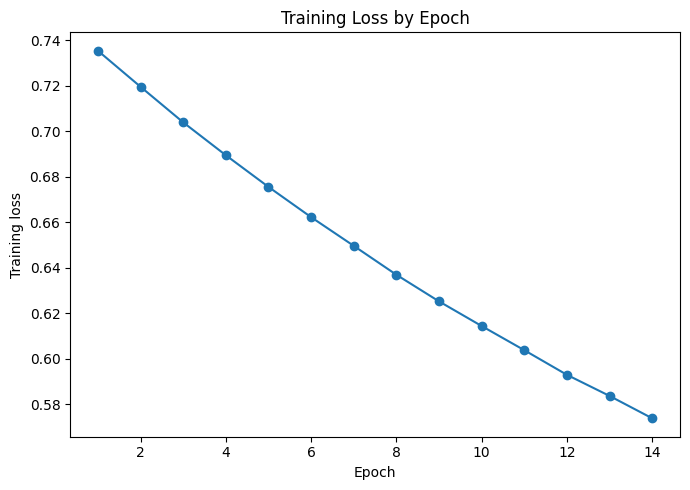

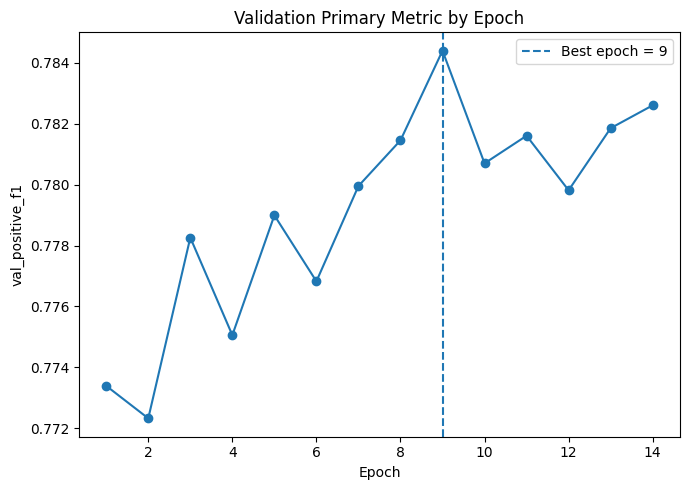

In [16]:

# Cell 14 — Plot training history

plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss by Epoch")
plt.tight_layout()
plt.savefig(PLOT_DIR / "training_loss.png", dpi=200)
plt.show()

primary_col = f"val_{CONFIG['evaluation']['primary_metric']}"
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df[primary_col], marker="o")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel(primary_col)
plt.title("Validation Primary Metric by Epoch")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "validation_primary_metric.png", dpi=200)
plt.show()


In [17]:

# Cell 15 — Load best checkpoint and select final threshold on validation only

checkpoint = torch.load(ARTIFACT_DIR / "slp_tfidf_best_checkpoint.pt", map_location=DEVICE)
model = SLPTextClassifier(input_dim=checkpoint["input_dim"]).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Recompute validation probabilities for the best model and choose the threshold using validation only.
val_logits, val_probs = predict_logits_and_probs(model, X_val_tensor, batch_size=CONFIG["model"]["batch_size"] * 8)
selected_threshold, threshold_grid_df = choose_threshold(y_val, val_probs, CONFIG["evaluation"])
val_metrics_final = compute_binary_metrics(y_val, val_probs, selected_threshold)

threshold_grid_df.to_csv(OUTPUT_DIR / "validation_threshold_grid.csv", index=False)
save_json({
    "threshold_strategy": CONFIG["evaluation"]["threshold_strategy"],
    "selected_threshold": selected_threshold,
    "validation_metrics_at_selected_threshold": val_metrics_final,
}, OUTPUT_DIR / "selected_threshold.json")

print(f"Loaded best checkpoint from epoch {checkpoint['best_epoch']}.")
print(f"Selected validation threshold: {selected_threshold:.4f}")
print("Validation metrics at selected threshold:")
print(pd.Series(val_metrics_final))


Loaded best checkpoint from epoch 9.
Selected validation threshold: 0.4849
Validation metrics at selected threshold:
threshold                0.484879
support                450.000000
positive_support       210.000000
negative_support       240.000000
positive_rate            0.466667
accuracy                 0.791111
balanced_accuracy        0.792560
positive_precision       0.756637
positive_recall          0.814286
positive_f1              0.784404
macro_f1                 0.790909
weighted_f1              0.791342
roc_auc                  0.883968
pr_auc                   0.879445
brier_score              0.203770
tn                     185.000000
fp                      55.000000
fn                      39.000000
tp                     171.000000
false_positive_rate      0.229167
false_negative_rate      0.185714
dtype: float64


In [18]:

# Cell 16 — Final test evaluation. This is the first time the test set is used for metrics.

test_logits, test_probs = predict_logits_and_probs(model, X_test_tensor, batch_size=CONFIG["model"]["batch_size"] * 8)
test_metrics = compute_binary_metrics(y_test, test_probs, selected_threshold)
test_preds = (test_probs >= selected_threshold).astype(int)

print("Test metrics:")
print(pd.Series(test_metrics))
print("\nClassification report:")
print(classification_report(y_test, test_preds, target_names=["NON_EXTREMIST", "EXTREMIST"], zero_division=0))

# Save metrics and classification report.
final_metrics = {
    "run_id": RUN_ID,
    "experiment_name": CONFIG["experiment_name"],
    "run_group": CONFIG["run_group"],
    "model_family": CONFIG["model"]["family"],
    "feature_family": CONFIG["features"]["type"],
    "dataset_sha256": dataset_manifest["data_sha256"],
    "split_version": CONFIG["splits"]["split_version"],
    "seed": CONFIG["random_seed"],
    "best_epoch": int(best_epoch),
    "training_seconds": float(training_seconds),
    "validation": val_metrics_final,
    "test": test_metrics,
    "pos_weight": pos_weight_value,
    "created_at": dt.datetime.now().isoformat(),
}

save_json(final_metrics, OUTPUT_DIR / "final_metrics.json")

report_dict = classification_report(
    y_test,
    test_preds,
    target_names=["NON_EXTREMIST", "EXTREMIST"],
    output_dict=True,
    zero_division=0,
)
save_json(report_dict, OUTPUT_DIR / "classification_report_test.json")

cm = confusion_matrix(y_test, test_preds, labels=[0, 1])
pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"]).to_csv(OUTPUT_DIR / "confusion_matrix_test.csv")


Test metrics:
threshold                0.484879
support                450.000000
positive_support       210.000000
negative_support       240.000000
positive_rate            0.466667
accuracy                 0.786667
balanced_accuracy        0.790179
positive_precision       0.737500
positive_recall          0.842857
positive_f1              0.786667
macro_f1                 0.786667
weighted_f1              0.786667
roc_auc                  0.881508
pr_auc                   0.877673
brier_score              0.205664
tn                     177.000000
fp                      63.000000
fn                      33.000000
tp                     177.000000
false_positive_rate      0.262500
false_negative_rate      0.157143
dtype: float64

Classification report:
               precision    recall  f1-score   support

NON_EXTREMIST       0.84      0.74      0.79       240
    EXTREMIST       0.74      0.84      0.79       210

     accuracy                           0.79       450
    macro a

In [19]:

# Cell 17 — Save standardized prediction files for train, validation, and test

def make_predictions_frame(split_name: str, split_df_part: pd.DataFrame, y_true: np.ndarray, logits: np.ndarray, probs: np.ndarray, threshold: float) -> pd.DataFrame:
    preds = (probs >= threshold).astype(int)
    out = pd.DataFrame({
        "run_id": RUN_ID,
        "row_id": split_df_part[id_col].to_numpy(),
        "text_hash": split_df_part["text_hash"].to_numpy(),
        "split": split_name,
        "y_true": y_true.astype(int),
        "y_pred": preds.astype(int),
        "y_prob": probs.astype(float),
        "logit": logits.astype(float),
        "threshold": float(threshold),
        "model_family": CONFIG["model"]["family"],
        "feature_family": CONFIG["features"]["type"],
        "seed": CONFIG["random_seed"],
    })
    return out

train_logits, train_probs = predict_logits_and_probs(model, X_train_tensor, batch_size=CONFIG["model"]["batch_size"] * 8)
# val_logits/val_probs and test_logits/test_probs already computed, but keep variable names explicit.

predictions_df = pd.concat([
    make_predictions_frame("train", train_df, y_train, train_logits, train_probs, selected_threshold),
    make_predictions_frame("val", val_df, y_val, val_logits, val_probs, selected_threshold),
    make_predictions_frame("test", test_df, y_test, test_logits, test_probs, selected_threshold),
], axis=0).reset_index(drop=True)

predictions_path = OUTPUT_DIR / "predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print(f"Saved standardized predictions to: {predictions_path}")
display(predictions_df.head())


Saved standardized predictions to: /kaggle/working/SLP_TF-IDF_research_ready_v1_20260620_203014_seed30/predictions.csv


,run_id,row_id,text_hash,split,y_true,y_pred,y_prob,logit,threshold,model_family,feature_family,seed
0,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_000554,55441e1eb6670938,train,1,1,0.595338,0.386075,0.484879,single_layer_perceptron,tfidf,30
1,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002502,28cdbce11bab5b2b,train,0,0,0.435189,-0.260711,0.484879,single_layer_perceptron,tfidf,30
2,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001473,4b3a689eb7162338,train,0,0,0.471888,-0.112566,0.484879,single_layer_perceptron,tfidf,30
3,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002571,206d387a462ac6e9,train,1,1,0.512842,0.051380,0.484879,single_layer_perceptron,tfidf,30
4,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002802,be2584f1beacf475,train,1,1,0.507965,0.031861,0.484879,single_layer_perceptron,tfidf,30


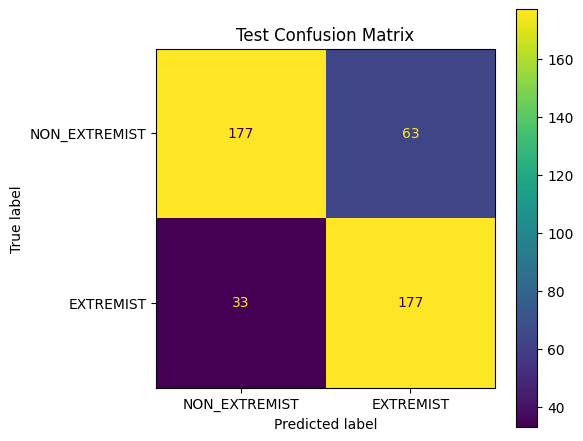

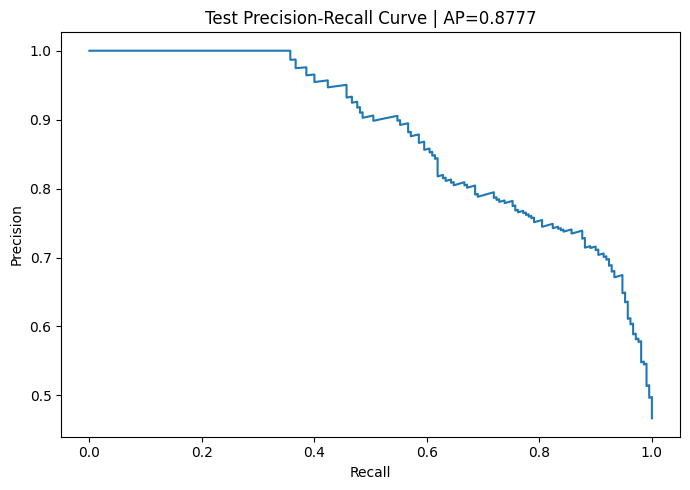

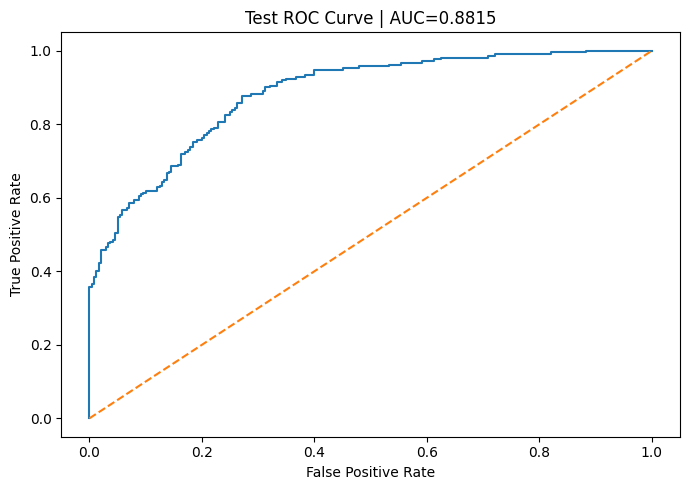

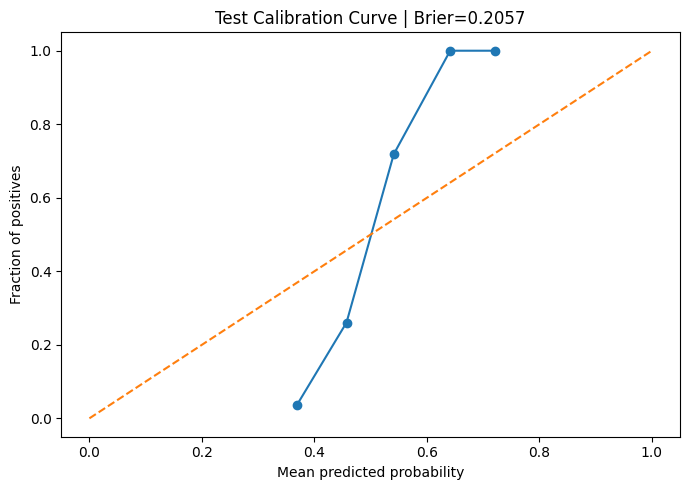

In [20]:

# Cell 18 — Diagnostic plots: confusion matrix, PR curve, ROC curve, and calibration

# Confusion matrix.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    display_labels=["NON_EXTREMIST", "EXTREMIST"],
    cmap=None,
    ax=ax,
)
ax.set_title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(PLOT_DIR / "confusion_matrix_test.png", dpi=200)
plt.show()

# Precision-recall curve.
precision, recall, _ = precision_recall_curve(y_test, test_probs)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Test Precision-Recall Curve | AP={test_metrics['pr_auc']:.4f}")
plt.tight_layout()
plt.savefig(PLOT_DIR / "precision_recall_curve_test.png", dpi=200)
plt.show()

# ROC curve.
if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Test ROC Curve | AUC={test_metrics['roc_auc']:.4f}")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "roc_curve_test.png", dpi=200)
    plt.show()

# Calibration curve.
if len(np.unique(y_test)) == 2:
    prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy="uniform")
    plt.figure(figsize=(7, 5))
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Test Calibration Curve | Brier={test_metrics['brier_score']:.4f}")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "calibration_curve_test.png", dpi=200)
    plt.show()


In [21]:

# Cell 19 — Exact linear interpretability for SLP over TF-IDF

# Because the SLP is a single linear layer, exact logit-scale feature contributions are simple:
# contribution_j = tfidf_value_j * weight_j.
# This is preferable to generic KernelSHAP for this model.

weights = model.linear.weight.detach().cpu().numpy().ravel()
bias = float(model.linear.bias.detach().cpu().numpy().ravel()[0])

# Global coefficient table.
coef_df = pd.DataFrame({
    "feature_name": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights),
})

# Contribution-aware importance: coefficient magnitude weighted by average observed train TF-IDF value.
mean_train_tfidf = np.asarray(X_train_vec.mean(axis=0)).ravel()
coef_df["mean_train_tfidf"] = mean_train_tfidf
coef_df["mean_abs_logit_contribution"] = np.abs(weights) * mean_train_tfidf

coef_df.sort_values("weight", ascending=False).head(CONFIG["artifacts"]["top_k_global_features"]).to_csv(
    EXPLAIN_DIR / "top_positive_features_by_weight.csv", index=False
)
coef_df.sort_values("weight", ascending=True).head(CONFIG["artifacts"]["top_k_global_features"]).to_csv(
    EXPLAIN_DIR / "top_negative_features_by_weight.csv", index=False
)
coef_df.sort_values("mean_abs_logit_contribution", ascending=False).head(CONFIG["artifacts"]["top_k_global_features"]).to_csv(
    EXPLAIN_DIR / "top_features_by_mean_abs_contribution.csv", index=False
)

print(f"Model bias/intercept: {bias:.4f}")
print("Top positive features by weight:")
display(coef_df.sort_values("weight", ascending=False).head(20))
print("Top negative features by weight:")
display(coef_df.sort_values("weight", ascending=True).head(20))


Model bias/intercept: 0.0119
Top positive features by weight:


,feature_name,weight,abs_weight,mean_train_tfidf,mean_abs_logit_contribution
2070,kill,0.480215,0.480215,0.029020,0.013936
2216,let kill,0.451100,0.451100,0.015477,0.006982
2212,let,0.411940,0.411940,0.018277,0.007529
2086,kill fucking,0.372477,0.372477,0.008505,0.003168
974,deserve,0.350296,0.350296,0.008257,0.002893
2565,murder,0.347918,0.347918,0.010437,0.003631
975,deserve die,0.345866,0.345866,0.007551,0.002612
1002,die,0.334960,0.334960,0.009359,0.003135
3354,shoot,0.329135,0.329135,0.010065,0.003313
221,attack,0.315082,0.315082,0.013283,0.004185


Top negative features by weight:


,feature_name,weight,abs_weight,mean_train_tfidf,mean_abs_logit_contribution
357,bitch,-0.495565,0.495565,0.038620,0.019139
4144,whore,-0.370753,0.370753,0.007439,0.002758
3282,scum world,-0.360655,0.360655,0.007226,0.002606
1033,disgusting people,-0.349180,0.349180,0.006744,0.002355
3989,vagina,-0.344428,0.344428,0.010467,0.003605
3303,senseless,-0.329799,0.329799,0.006190,0.002041
3304,senseless disgusting,-0.329204,0.329204,0.006087,0.002004
876,cunt,-0.326910,0.326910,0.007361,0.002406
1746,hoe,-0.326105,0.326105,0.008541,0.002785
1484,fucking scum,-0.322547,0.322547,0.008068,0.002602


In [22]:

# Cell 20 — Save local explanations for selected test examples

def classify_error_type(y_true: int, y_pred: int) -> str:
    if y_true == 0 and y_pred == 1:
        return "false_positive"
    if y_true == 1 and y_pred == 0:
        return "false_negative"
    if y_true == 1 and y_pred == 1:
        return "true_positive"
    return "true_negative"


def select_examples_for_explanation(pred_df: pd.DataFrame, k: int) -> pd.DataFrame:
    dfp = pred_df.copy()
    dfp["error_type"] = [classify_error_type(t, p) for t, p in zip(dfp["y_true"], dfp["y_pred"])]
    dfp["confidence"] = np.where(dfp["y_pred"] == 1, dfp["y_prob"], 1 - dfp["y_prob"])
    dfp["distance_to_threshold"] = (dfp["y_prob"] - dfp["threshold"]).abs()

    selected = []
    for error_type in ["false_positive", "false_negative", "true_positive", "true_negative"]:
        subset = dfp[dfp["error_type"] == error_type]
        if len(subset) > 0:
            selected.append(subset.sort_values("confidence", ascending=False).head(k))
            selected.append(subset.sort_values("distance_to_threshold", ascending=True).head(k))

    if selected:
        out = pd.concat(selected, axis=0).drop_duplicates(subset=["row_id"])
    else:
        out = dfp.head(0)
    return out


def local_contributions_for_rows(
    X_sparse: csr_matrix,
    split_df_part: pd.DataFrame,
    pred_df_part: pd.DataFrame,
    selected_row_ids: List[str],
    weights: np.ndarray,
    feature_names: np.ndarray,
    top_k: int,
) -> pd.DataFrame:
    row_id_to_position = {rid: i for i, rid in enumerate(split_df_part[id_col].tolist())}
    pred_lookup = pred_df_part.set_index("row_id")
    rows = []

    for rid in selected_row_ids:
        if rid not in row_id_to_position:
            continue
        i = row_id_to_position[rid]
        sparse_row = X_sparse.getrow(i)
        cols = sparse_row.indices
        vals = sparse_row.data
        contribs = vals * weights[cols]

        if len(contribs) == 0:
            continue

        local_df = pd.DataFrame({
            "feature_name": feature_names[cols],
            "tfidf_value": vals,
            "weight": weights[cols],
            "logit_contribution": contribs,
        })

        top_pos = local_df.sort_values("logit_contribution", ascending=False).head(top_k).copy()
        top_pos["direction"] = "toward_EXTREMIST"
        top_neg = local_df.sort_values("logit_contribution", ascending=True).head(top_k).copy()
        top_neg["direction"] = "toward_NON_EXTREMIST"
        top_local = pd.concat([top_pos, top_neg], axis=0)

        pred_info = pred_lookup.loc[rid]
        for rank, (_, r) in enumerate(top_local.iterrows(), start=1):
            rows.append({
                "run_id": RUN_ID,
                "row_id": rid,
                "split": "test",
                "y_true": int(pred_info["y_true"]),
                "y_pred": int(pred_info["y_pred"]),
                "y_prob": float(pred_info["y_prob"]),
                "threshold": float(pred_info["threshold"]),
                "error_type": classify_error_type(int(pred_info["y_true"]), int(pred_info["y_pred"])),
                "rank": rank,
                "direction": r["direction"],
                "feature_name": r["feature_name"],
                "tfidf_value": float(r["tfidf_value"]),
                "weight": float(r["weight"]),
                "logit_contribution": float(r["logit_contribution"]),
            })

    return pd.DataFrame(rows)


test_pred_df = predictions_df[predictions_df["split"] == "test"].copy()
selected_examples_df = select_examples_for_explanation(
    test_pred_df,
    k=CONFIG["artifacts"]["top_k_error_examples"],
)

local_explanations_df = local_contributions_for_rows(
    X_sparse=X_test_vec,
    split_df_part=test_df,
    pred_df_part=test_pred_df,
    selected_row_ids=selected_examples_df["row_id"].tolist(),
    weights=weights,
    feature_names=feature_names,
    top_k=CONFIG["artifacts"]["top_k_local_explanations"],
)

selected_examples_df.to_csv(ERROR_DIR / "selected_examples_for_error_analysis.csv", index=False)
local_explanations_df.to_csv(EXPLAIN_DIR / "local_linear_explanations_test.csv", index=False)

print(f"Selected examples: {len(selected_examples_df)}")
print(f"Local explanation rows: {len(local_explanations_df)}")
display(selected_examples_df.head())
display(local_explanations_df.head())


Selected examples: 183
Local explanation rows: 3494


,run_id,row_id,text_hash,split,y_true,y_pred,y_prob,logit,threshold,model_family,feature_family,seed,error_type,confidence,distance_to_threshold
2609,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002637,4b6849ca379fc123,test,0,1,0.572078,0.290335,0.484879,single_layer_perceptron,tfidf,30,false_positive,0.572078,0.087199
2645,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_000936,d71ef7a97f8aa3d3,test,0,1,0.570307,0.283102,0.484879,single_layer_perceptron,tfidf,30,false_positive,0.570307,0.085428
2821,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_000275,3ea5d6f19dd99707,test,0,1,0.564256,0.258453,0.484879,single_layer_perceptron,tfidf,30,false_positive,0.564256,0.079377
2936,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_000353,1b9502e2df95190d,test,0,1,0.560027,0.241273,0.484879,single_layer_perceptron,tfidf,30,false_positive,0.560027,0.075149
2554,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001520,8369465fce3f5268,test,0,1,0.555236,0.221851,0.484879,single_layer_perceptron,tfidf,30,false_positive,0.555236,0.070358


,run_id,row_id,split,y_true,y_pred,y_prob,threshold,error_type,rank,direction,feature_name,tfidf_value,weight,logit_contribution
0,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002637,test,0,1,0.572078,0.484879,false_positive,1,toward_EXTREMIST,doctors,0.548951,0.163376,0.089685
1,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002637,test,0,1,0.572078,0.484879,false_positive,2,toward_EXTREMIST,attack,0.124758,0.315082,0.039309
2,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002637,test,0,1,0.572078,0.484879,false_positive,3,toward_EXTREMIST,ground,0.216284,0.144443,0.031241
3,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002637,test,0,1,0.572078,0.484879,false_positive,4,toward_EXTREMIST,fightback,0.189589,0.157255,0.029814
4,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002637,test,0,1,0.572078,0.484879,false_positive,5,toward_EXTREMIST,doctors fightback,0.191471,0.149466,0.028618


In [23]:

# Cell 21 — Error analysis table for qualitative review

error_df = test_pred_df.copy()
error_df["error_type"] = [classify_error_type(t, p) for t, p in zip(error_df["y_true"], error_df["y_pred"])]
error_df["confidence"] = np.where(error_df["y_pred"] == 1, error_df["y_prob"], 1 - error_df["y_prob"])
error_df["distance_to_threshold"] = (error_df["y_prob"] - error_df["threshold"]).abs()
error_df["manual_error_category"] = ""  # fill during qualitative analysis
error_df["manual_notes"] = ""

if CONFIG["artifacts"]["save_text_in_error_files"]:
    error_df = error_df.merge(test_df[[id_col, text_col]], left_on="row_id", right_on=id_col, how="left")
    error_df = error_df.drop(columns=[id_col])

error_df.to_csv(ERROR_DIR / "test_error_analysis_template.csv", index=False)

print("Error counts:")
print(error_df["error_type"].value_counts())
print(f"Saved error-analysis template to: {ERROR_DIR / 'test_error_analysis_template.csv'}")
display(error_df.sort_values("confidence", ascending=False).head(10))


Error counts:
error_type
true_negative     177
true_positive     177
false_positive     63
false_negative     33
Name: count, dtype: int64
Saved error-analysis template to: /kaggle/working/SLP_TF-IDF_research_ready_v1_20260620_203014_seed30/error_analysis/test_error_analysis_template.csv


,run_id,row_id,text_hash,split,y_true,y_pred,y_prob,logit,threshold,model_family,feature_family,seed,error_type,confidence,distance_to_threshold,manual_error_category,manual_notes
2849,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001278,1f9543a5cb656104,test,1,1,0.721197,0.950405,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.721197,0.236318,,
2977,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001770,1a843e6f04a42c47,test,0,0,0.302459,-0.835616,0.484879,single_layer_perceptron,tfidf,30,true_negative,0.697541,0.182420,,
2996,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001723,0f3c1bc675ba20d6,test,0,0,0.307550,-0.811597,0.484879,single_layer_perceptron,tfidf,30,true_negative,0.692450,0.177328,,
2730,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001326,b8a1f6df8d270caf,test,1,1,0.691016,0.804872,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.691016,0.206137,,
2908,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_002501,86568d6c18d654eb,test,0,0,0.309721,-0.801426,0.484879,single_layer_perceptron,tfidf,30,true_negative,0.690279,0.175158,,
2808,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001321,3e04d9a3235458e2,test,1,1,0.689980,0.800025,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.689980,0.205101,,
2614,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001392,81a8c6df9fb26b27,test,1,1,0.689749,0.798946,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.689749,0.204870,,
2644,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001337,2a8bd4ac22f5aa9d,test,1,1,0.688522,0.793219,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.688522,0.203643,,
2683,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001248,0df04af6fda0afec,test,1,1,0.684851,0.776155,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.684851,0.199972,,
2784,SLP_TF-IDF_research_ready_v1_20260620_203014_s...,row_001295,206578331590ad61,test,1,1,0.684539,0.774712,0.484879,single_layer_perceptron,tfidf,30,true_positive,0.684539,0.199661,,


In [24]:

# Cell 22 — Optional: display text for manual error review inside the notebook only

# For sensitive data, raw text is not saved by default. Set SHOW_TEXT_EXAMPLES=True only in a secure/private environment.
SHOW_TEXT_EXAMPLES = False

if SHOW_TEXT_EXAMPLES:
    review_df = error_df.merge(test_df[[id_col, text_col]], left_on="row_id", right_on=id_col, how="left")
    display_cols = ["row_id", "error_type", "y_true", "y_pred", "y_prob", "confidence", text_col]
    display(review_df.sort_values("confidence", ascending=False)[display_cols].head(20))
else:
    print("Raw text display is disabled. Set SHOW_TEXT_EXAMPLES=True for local qualitative review.")


Raw text display is disabled. Set SHOW_TEXT_EXAMPLES=True for local qualitative review.


In [25]:

# Cell 23 — Artifact inventory and final reproducibility summary

artifact_inventory = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        artifact_inventory.append({
            "relative_path": str(path.relative_to(OUTPUT_DIR)),
            "size_bytes": path.stat().st_size,
        })

artifact_inventory_df = pd.DataFrame(artifact_inventory)
artifact_inventory_df.to_csv(OUTPUT_DIR / "artifact_inventory.csv", index=False)

summary = {
    "run_id": RUN_ID,
    "output_dir": str(OUTPUT_DIR.resolve()),
    "best_epoch": int(best_epoch),
    "selected_threshold": float(selected_threshold),
    "test_positive_f1": test_metrics["positive_f1"],
    "test_positive_precision": test_metrics["positive_precision"],
    "test_positive_recall": test_metrics["positive_recall"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_pr_auc": test_metrics["pr_auc"],
    "test_roc_auc": test_metrics["roc_auc"],
    "test_confusion_matrix": {
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
    },
}

save_json(summary, OUTPUT_DIR / "run_summary.json")

print("Run complete.")
print(json.dumps(summary, indent=2))
print("\nArtifacts:")
display(artifact_inventory_df)


Run complete.
{
  "run_id": "SLP_TF-IDF_research_ready_v1_20260620_203014_seed30",
  "output_dir": "/kaggle/working/SLP_TF-IDF_research_ready_v1_20260620_203014_seed30",
  "best_epoch": 9,
  "selected_threshold": 0.4848787878787879,
  "test_positive_f1": 0.7866666666666666,
  "test_positive_precision": 0.7375,
  "test_positive_recall": 0.8428571428571429,
  "test_macro_f1": 0.7866666666666666,
  "test_pr_auc": 0.8776725982316474,
  "test_roc_auc": 0.8815079365079366,
  "test_confusion_matrix": {
    "tn": 177,
    "fp": 63,
    "fn": 33,
    "tp": 177
  }
}

Artifacts:


,relative_path,size_bytes
0,artifacts/feature_names.csv,43024
1,artifacts/slp_tfidf_best_checkpoint.pt,21365
2,artifacts/tfidf_vectorizer.pkl,150605
3,classification_report_test.json,619
4,config.json,1510
5,confusion_matrix_test.csv,43
6,dataset_manifest.json,392
7,error_analysis/selected_examples_for_error_ana...,43063
8,error_analysis/test_error_analysis_template.csv,106260
9,explanations/local_linear_explanations_test.csv,751370
